# 01 — Exploración del dataset

Objetivo de este notebook:
- Cargar el dataset Oxford-IIIT Pet.
- **Verificar empíricamente los valores del trimap** (no asumir la codificación).
- Ver imágenes reales junto a sus máscaras.
- Entender las dimensiones y características de los datos antes de aplicar K-Means.

### 1. Preparar el entorno

Los notebooks viven en `notebooks/` pero los módulos en `src/`. La siguiente
celda agrega la raíz del proyecto al path de Python para poder importarlos.


In [6]:
import sys
from pathlib import Path

# Agrega la raíz del proyecto al path para poder importar desde src/
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src import config
from src import preprocessing as pp

print("Módulos cargados correctamente")
print("Imágenes en:", config.IMAGES_DIR)
print("Trimaps en:", config.TRIMAPS_DIR)

Módulos cargados correctamente
Imágenes en: C:\Proyectos de VS\image-segmentation-kmeans\data\raw\images
Trimaps en: C:\Proyectos de VS\image-segmentation-kmeans\data\raw\annotations\trimaps


### 2. Verificar los valores del trimap

No asumimos la codificación del trimap: la comprobamos abriendo varias máscaras
reales. Lo esperado es {1, 2, 3} (1=animal, 2=fondo, 3=borde), pero hay que
confirmarlo antes de construir cualquier evaluación sobre esa suposición.

In [7]:
# Emparejar imágenes con sus máscaras (filtra basura ._ y archivos .mat)
pairs = pp.list_pairs(config.IMAGES_DIR, config.TRIMAPS_DIR)
print("Pares imagen-máscara encontrados:", len(pairs))

# Verificar empíricamente los valores del trimap sobre una muestra
trimap_paths = [mask for _, mask in pairs]
valores = pp.verify_trimap_values(trimap_paths, max_files=200)
print("Valores únicos en los trimaps:", valores)

Pares imagen-máscara encontrados: 7390
Valores únicos en los trimaps: [1, 2, 3]


### 3. Ver imágenes reales con sus máscaras

Cargamos algunas imágenes junto a su trimap para entender visualmente qué
tan bien (o mal) separa el color al animal del fondo. El trimap se ve casi
negro en crudo (valores 1,2,3), así que lo mostramos con colores para
distinguir animal / fondo / borde.

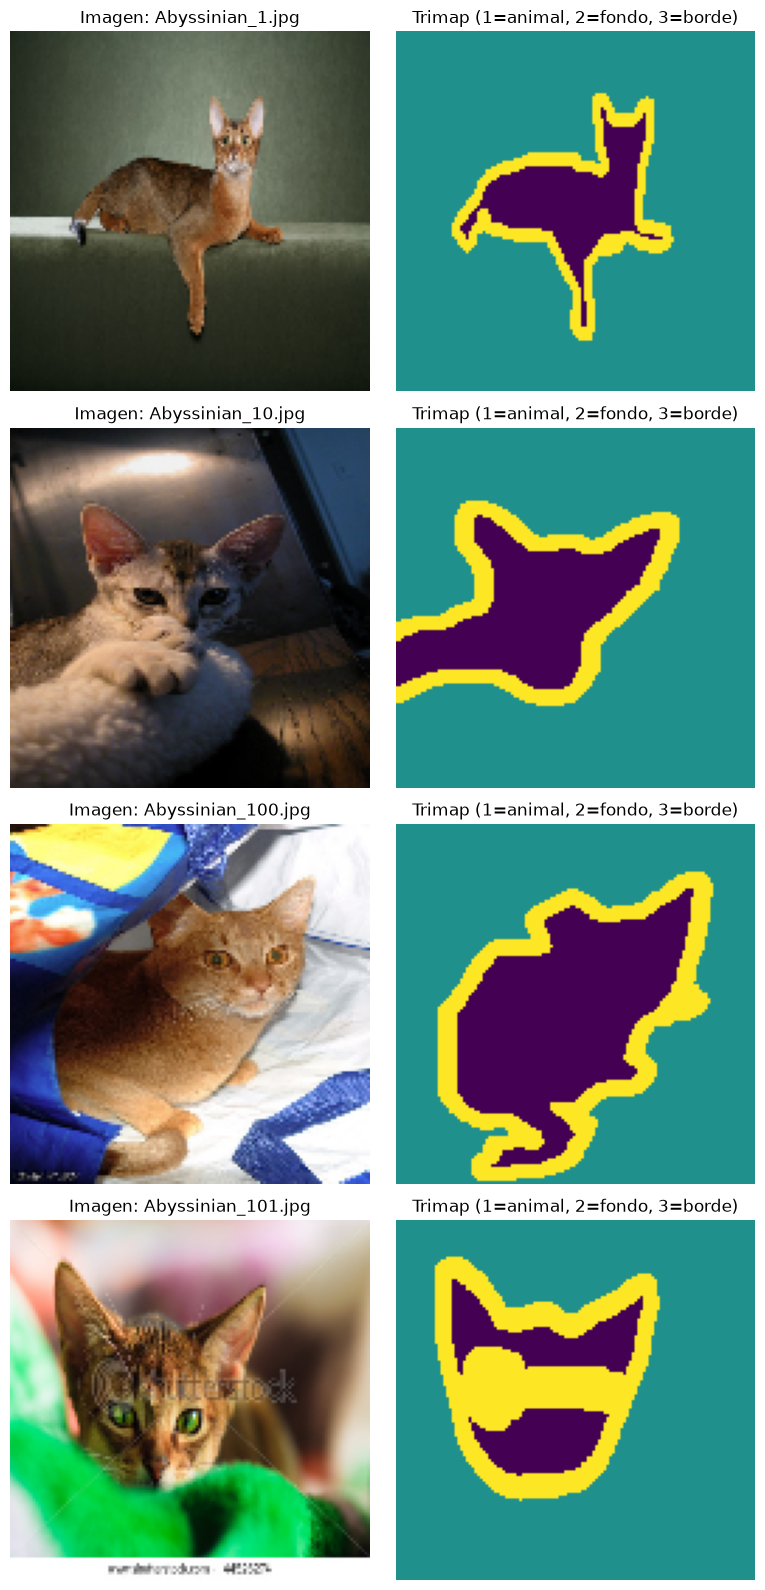

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Tomamos 4 pares de ejemplo
ejemplos = pairs[:4]

fig, axes = plt.subplots(len(ejemplos), 2, figsize=(8, 4 * len(ejemplos)))

for i, (img_path, mask_path) in enumerate(ejemplos):
    img = pp.load_image(img_path, resize_to=config.RESIZE_TO)
    mask = pp.load_mask(mask_path, resize_to=config.RESIZE_TO)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Imagen: {img_path.name}")
    axes[i, 0].axis("off")

    # Mostrar el trimap con colores (no en crudo, que se ve negro)
    axes[i, 1].imshow(mask, cmap="viridis")
    axes[i, 1].set_title("Trimap (1=animal, 2=fondo, 3=borde)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

### 4. Proporción animal / fondo / borde

Medimos qué fracción de píxeles ocupa en promedio cada clase del trimap.
Esto da contexto para la evaluación: si el animal ocupa poco de la imagen,
el baseline "todo-foreground" tendrá IoU bajo, y sabemos qué números esperar.

In [9]:
# Medir la proporción de cada clase sobre una muestra de trimaps
muestra = pairs[:300]

frac_animal, frac_fondo, frac_borde = [], [], []

for _, mask_path in muestra:
    mask = pp.load_mask(mask_path, resize_to=config.RESIZE_TO)
    total = mask.size
    frac_animal.append((mask == config.TRIMAP_FOREGROUND).sum() / total)
    frac_fondo.append((mask == config.TRIMAP_BACKGROUND).sum() / total)
    frac_borde.append((mask == config.TRIMAP_BOUNDARY).sum() / total)

print(f"Muestra: {len(muestra)} imágenes")
print(f"Animal (foreground): {np.mean(frac_animal):.1%} en promedio")
print(f"Fondo (background):  {np.mean(frac_fondo):.1%} en promedio")
print(f"Borde (ignorado):    {np.mean(frac_borde):.1%} en promedio")

Muestra: 300 imágenes
Animal (foreground): 29.3% en promedio
Fondo (background):  58.1% en promedio
Borde (ignorado):    12.6% en promedio
